<a href="https://colab.research.google.com/github/informatics-HSJ/AirKorea/blob/main/%EC%97%90%EC%96%B4%EC%BD%94%EB%A6%AC%EC%95%84_%ED%85%8C%EC%8A%A4%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. 준비

In [65]:
import pandas as pd
import requests
import xml.etree.ElementTree as ET

In [56]:
url = 'http://apis.data.go.kr/B552584/ArpltnInforInqireSvc/getCtprvnRltmMesureDnsty'
key = '4QSXxjaO236+NZsNsXOaYJrM2U4LqUAgzepFY/fcSdu7bcnSxxXoI28FtTGJpQnyT8Ha4pkcL66Wyc0AkxUozA=='

sidoName = ['전국', '서울', '부산', '대구', '인천', '광주', '대전', '울산', '경기', '강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주', '세종']

# 1. 에어코리아 데이터 테스트

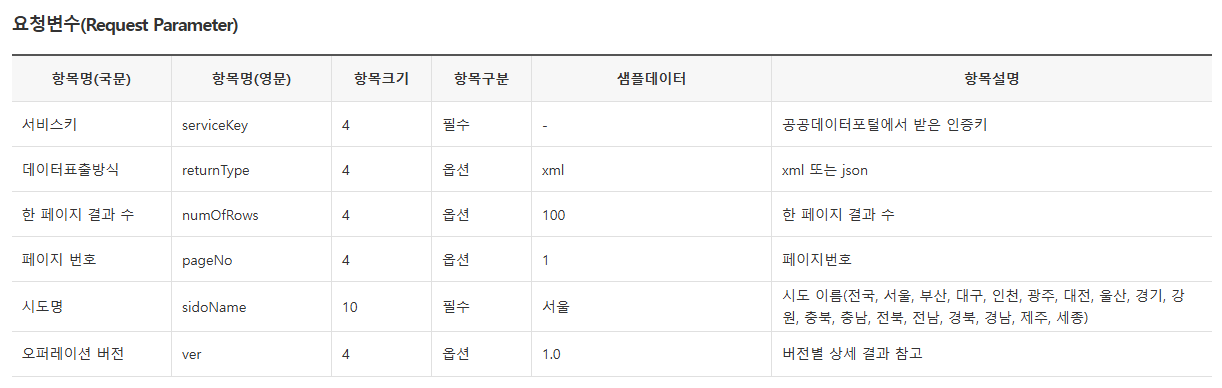

In [ ]:
params ={
    'serviceKey' : key,
    'returnType' : 'xml',
    'numOfRows' : '100',
    'pageNo' : '1',
    'sidoName' : sidoName[0],
    'ver' : '1.5'
}

response = requests.get(url, params=params)

response.content

In [ ]:
root = ET.fromstring(response.content)

data = []

body = root.find('body')
items = body.find('items')

for item in items.findall('item'):
    entry = {}
    for child in item:
        entry[child.tag] = child.text
    data.append(entry)

df = pd.DataFrame(data)

df.columns

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/공공데이터/에어코리아/에어코리아 항목명.csv'

column_mapping_df = pd.read_csv(file_path, header=None)
column_mapping_df

In [ ]:
original_names = column_mapping_df.iloc[:, 0].tolist()
new_names = column_mapping_df.iloc[:, 1].tolist()
rename_dict = dict(zip(original_names, new_names))

df_renamed = df.rename(columns=rename_dict)

df_renamed

In [92]:
# First, save df_renamed to a CSV file to be loaded by the Streamlit app.
# This ensures the Streamlit app has access to the processed data.
df_renamed.to_csv('air_quality_data.csv', index=False, encoding='utf-8-sig')

# 새 섹션

In [93]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

# Data loading and preprocessing function, cached for performance
@st.cache_data
def load_data():
    try:
        df = pd.read_csv('air_quality_data.csv', encoding='utf-8-sig')
    except FileNotFoundError:
        st.error("데이터 파일 'air_quality_data.csv'를 찾을 수 없습니다. 이전 셀에서 데이터를 저장했는지 확인해주세요.")
        return pd.DataFrame() # Return empty DataFrame on error

    df['측정일시'] = pd.to_datetime(df['측정일시'])

    # List of columns that represent measurable air quality values
    measurable_cols = [
        '아황산가스 농도', '일산화탄소 농도', '오존 농도', '이산화질소 농도',
        '미세먼지(PM10) 농도', '미세먼지(PM2.5) 농도'
    ]

    # Convert measurable columns to numeric, coercing errors to NaN and filling NaN with 0
    for col in measurable_cols:
        if col in df.columns:
            # Replace '-' with NaN before converting to numeric
            df[col] = df[col].replace('-', pd.NA)
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    return df

df_renamed_app = load_data()

st.title('에어코리아 대기질 데이터 분석 웹앱')

if df_renamed_app.empty:
    st.warning("데이터가 없어 웹앱을 표시할 수 없습니다. 데이터를 먼저 로드해주세요.")
else:
    # Sidebar for filters
    st.sidebar.header('필터')

    # Select box for sidoName
    # Ensure unique sido names and sort them for better UI
    sido_options = sorted(df_renamed_app['시도명'].unique().tolist())
    selected_sido = st.sidebar.selectbox('시도 선택', sido_options)

    # Select box for measurable item
    measurable_items_all = [ # All possible measurable items based on the context
        '아황산가스 농도', '일산화탄소 농도', '오존 농도', '이산화질소 농도',
        '미세먼지(PM10) 농도', '미세먼지(PM2.5) 농도'
    ]
    # Filter for available and numeric items in the loaded data
    available_items = [item for item in measurable_items_all if item in df_renamed_app.columns and pd.api.types.is_numeric_dtype(df_renamed_app[item])]

    if not available_items:
        st.error("시각화할 수 있는 측정 항목이 없습니다. 데이터프레임 컬럼을 확인해주세요.")
    else:
        selected_item = st.sidebar.selectbox('항목 선택', available_items)

        # Filter data based on selections
        filtered_df = df_renamed_app[df_renamed_app['시도명'] == selected_sido].copy()

        # Group by '측정일시' and calculate mean for the selected item
        # Sort by '측정일시' for correct time series plotting
        daily_avg = filtered_df.groupby('측정일시')[selected_item].mean().reset_index().sort_values(by='측정일시')

        if daily_avg.empty:
            st.warning(f"{selected_sido}에 대한 {selected_item} 데이터가 없습니다. 다른 시도나 항목을 선택해보세요.")
        else:
            # Plotly Express time series visualization
            fig = px.line(daily_avg, x='측정일시', y=selected_item,
                          title=f'{selected_sido} {selected_item} 시간별 변화',
                          labels={'측정일시': '측정일시', selected_item: f'평균 {selected_item}'})

            fig.update_layout(hovermode='x unified')
            st.plotly_chart(fig)

            # Display descriptive statistics
            st.subheader(f'{selected_sido} {selected_item} 요약 통계:')
            st.write(daily_avg[selected_item].describe())

Writing app.py


In [95]:
# Install Streamlit and pyngrok
# Use -q for quiet installation
!pip install -q streamlit pyngrok

# Run the Streamlit app in the background using nohup and redirect output to /dev/null
# This prevents it from blocking the cell execution and keeps the notebook clean.
# 'streamlit run app.py &' runs the app, 'nohup' keeps it running even if the shell exits.
!nohup streamlit run app.py > output.log 2>&1 &

import time
time.sleep(5) # Give Streamlit a moment to start up

from pyngrok import ngrok

# Terminate any existing ngrok tunnels to avoid conflicts
ngrok.kill()

# Set your ngrok authtoken. You can get yours from https://dashboard.ngrok.com/get-started/your-authtoken
# Replace "YOUR_AUTHTOKEN" with your actual token.
ngrok.set_auth_token("YOUR_AUTHTOKEN")

# Establish a new tunnel to the Streamlit app's default port (8501)
public_url = ngrok.connect(addr="8501", proto="http")
print(f"Streamlit App URL: {public_url}")
print("Please click on the URL above to access your Streamlit app.")
print("To stop the Streamlit app, you can run: !pkill streamlit")

ERROR:pyngrok.process.ngrok:t=2026-07-29T06:45:37+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-07-29T06:45:37+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.